In [253]:
!pip install -Uqq fastbook
import fastbook
fastbook.setup_book()

In [254]:
#hide
from fastai.vision.all import *
from fastbook import *

matplotlib.rc('image', cmap='Greys')

In [255]:
path = untar_data(URLs.MNIST_SAMPLE)
print(path)

/Users/manojkumar/.fastai/data/mnist_sample


In [256]:
#hide
Path.BASE_PATH = path
path

Path('.')

In [257]:
path.ls() 

[Path('valid'), Path('labels.csv'), Path('.DS_Store'), Path('train')]

In [258]:
(path/'train').ls()

[Path('train/.DS_Store'), Path('train/7'), Path('train/3')]

In [259]:
threes = (path/'train'/'3').ls().sorted()
sevens = (path/'train'/'7').ls().sorted()
threes

(#6131) [Path('train/3/10.png'), Path('train/3/10000.png'), Path('train/3/10011.png'), Path('train/3/10031.png'), Path('train/3/10034.png'), Path('train/3/10042.png'), Path('train/3/10052.png'), Path('train/3/1007.png'), Path('train/3/10074.png'), Path('train/3/10091.png'), Path('train/3/10093.png'), Path('train/3/10097.png'), Path('train/3/10099.png'), Path('train/3/10116.png'), Path('train/3/10125.png'), Path('train/3/10137.png'), Path('train/3/10141.png'), Path('train/3/10144.png'), Path('train/3/10155.png'), Path('train/3/10161.png'), Path('train/3/10206.png'), Path('train/3/1021.png'), Path('train/3/10210.png'), Path('train/3/10214.png'), Path('train/3/10238.png'), Path('train/3/10260.png'), Path('train/3/10278.png'), Path('train/3/10282.png'), Path('train/3/10314.png'), Path('train/3/10322.png'), Path('train/3/10328.png'), Path('train/3/10329.png'), Path('train/3/10330.png'), Path('train/3/10349.png'), Path('train/3/1035.png'), Path('train/3/10360.png'), Path('train/3/10369.png')

In [260]:
im3_path = threes[1]
im3 = Image.open(im3_path)
im3,  im3_path

(<PIL.PngImagePlugin.PngImageFile image mode=L size=28x28>,
 Path('train/3/10000.png'))

In [261]:
array(im3)[4:10,4:10]

array([[  0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,  29],
       [  0,   0,   0,  48, 166, 224],
       [  0,  93, 244, 249, 253, 187],
       [  0, 107, 253, 253, 230,  48],
       [  0,   3,  20,  20,  15,   0]], dtype=uint8)

In [262]:
tensor(im3)[4:10,4:10]

tensor([[  0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,  29],
        [  0,   0,   0,  48, 166, 224],
        [  0,  93, 244, 249, 253, 187],
        [  0, 107, 253, 253, 230,  48],
        [  0,   3,  20,  20,  15,   0]], dtype=torch.uint8)

In [263]:
#hide_output
im3_t = tensor(im3)
df = pd.DataFrame(im3_t[4:15,4:22])
df.style.set_properties(**{'font-size':'6pt'}).background_gradient('Blues')

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,29,150,195,254,255,254,176,193,150,96,0,0,0
2,0,0,0,48,166,224,253,253,234,196,253,253,253,253,233,0,0,0
3,0,93,244,249,253,187,46,10,8,4,10,194,253,253,233,0,0,0
4,0,107,253,253,230,48,0,0,0,0,0,192,253,253,156,0,0,0
5,0,3,20,20,15,0,0,0,0,0,43,224,253,245,74,0,0,0
6,0,0,0,0,0,0,0,0,0,0,249,253,245,126,0,0,0,0
7,0,0,0,0,0,0,0,14,101,223,253,248,124,0,0,0,0,0
8,0,0,0,0,0,11,166,239,253,253,253,187,30,0,0,0,0,0
9,0,0,0,0,0,16,248,250,253,253,253,253,232,213,111,2,0,0


In [264]:
seven_tensors = [tensor(Image.open(o)) for o in sevens]
three_tensors = [tensor(Image.open(o)) for o in threes]
len(three_tensors),len(seven_tensors)

(6131, 6265)

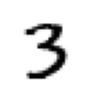

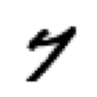

In [265]:
show_image(three_tensors[1]), show_image(seven_tensors[1]);

In [266]:
stacked_sevens = torch.stack(seven_tensors).float()/255
stacked_threes = torch.stack(three_tensors).float()/255
stacked_threes.shape, stacked_sevens.shape

(torch.Size([6131, 28, 28]), torch.Size([6265, 28, 28]))

In [267]:
len(stacked_threes.shape),  len(stacked_sevens.shape)

(3, 3)

In [268]:
#alternative way to find the tensor rank 

In [269]:
stacked_threes.ndim, stacked_sevens.ndim

(3, 3)

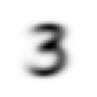

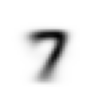

In [270]:
mean3 = stacked_threes.mean(0)
mean7 = stacked_sevens.mean(0)
show_image(mean3);show_image(mean7);

(<Axes: >, <Axes: >)

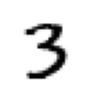

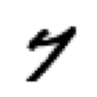

In [271]:
a_3 = stacked_threes[1]
a_7=stacked_sevens[1]
show_image(a_3),show_image(a_7)

In [272]:
dist_3_abs = (a_3 - mean3).abs().mean()
dist_3_sqr = ((a_3 - mean3)**2).mean().sqrt()
dist_3_abs,dist_3_sqr

(tensor(0.1114), tensor(0.2021))

In [273]:
dist_7_abs = (a_3 - mean7).abs().mean()
dist_7_sqr = ((a_3 - mean7)**2).mean().sqrt()
dist_7_abs,dist_7_sqr

(tensor(0.1586), tensor(0.3021))

In [274]:
dist_7_abs = (a_3 - mean7).abs().mean()
dist_7_sqr = ((a_3 - mean7)**2).mean().sqrt()
dist_7_abs,dist_7_sqr

(tensor(0.1586), tensor(0.3021))

In [275]:
data = [[1,2,3],[4,5,6]]
arr = array (data)
tns = tensor(data)

In [276]:
arr

array([[1, 2, 3],
       [4, 5, 6]])

In [277]:
tns

tensor([[1, 2, 3],
        [4, 5, 6]])

In [278]:
tns[:,1]
# here we are slicing the tensor to get all rows and the second column (index 1) of the tensor. This will return a 1D tensor containing the values from the second column of the original tensor.

tensor([2, 5])

In [279]:
tns[1,1:3]
#

tensor([5, 6])

In [280]:
#And you can use the standard operators such as +, -, *, /:
tns+1

tensor([[2, 3, 4],
        [5, 6, 7]])

In [281]:
tns.type()

'torch.LongTensor'

In [282]:
#computing matrix using broadcasting

In [283]:
valid_3_tens = torch.stack([tensor(Image.open(o)) 
                            for o in (path/'valid'/'3').ls()])
valid_3_tens = valid_3_tens.float()/255
valid_7_tens = torch.stack([tensor(Image.open(o)) 
                            for o in (path/'valid'/'7').ls()])
valid_7_tens = valid_7_tens.float()/255
valid_3_tens.shape,valid_7_tens.shape

(torch.Size([1010, 28, 28]), torch.Size([1028, 28, 28]))

In [284]:
def mnist_distance(a,b): return (a-b).abs().mean((-1,-2))
mnist_distance(a_3, mean3)

tensor(0.1114)

In [285]:
valid_3_dist = mnist_distance(valid_3_tens, mean3)
valid_3_dist, valid_3_dist.shape

(tensor([0.1634, 0.1145, 0.1363,  ..., 0.1105, 0.1111, 0.1640]),
 torch.Size([1010]))

In [286]:
#Example
tensor([1,2,3]) + tensor(1)

tensor([2, 3, 4])

In [287]:
(valid_3_tens-mean3).shape

torch.Size([1010, 28, 28])

In [288]:
def is_3(x): return mnist_distance(x,mean3) < mnist_distance(x,mean7)

In [289]:
is_3(valid_3_tens)

tensor([True, True, True,  ..., True, True, True])

In [290]:
accuracy_3s =      is_3(valid_3_tens).float() .mean()
accuracy_7s = (1 - is_3(valid_7_tens).float()).mean()
accuracy_3s, accuracy_7s

(tensor(0.9168), tensor(0.9854))

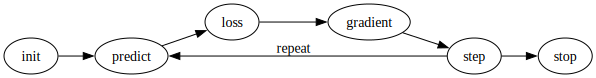

In [291]:
##GCD
#Sequence of numbers from 0 to 99

#id gradient_descent
#caption The gradient descent process
#alt Graph showing the steps for Gradient Descent
gv('''
init->predict->loss->gradient->step->stop
step->predict[label=repeat]
''')

In [292]:
def f(x): return x**2

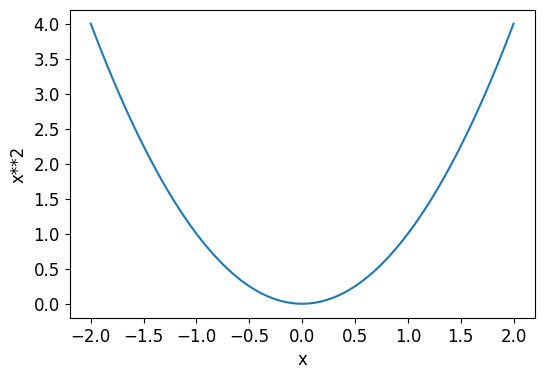

In [293]:
plot_function(f, 'x', 'x**2')

The sequence of steps we described earlier starts by picking some random value for a parameter, and calculating the value of the loss:
The sequence of steps we described earlier starts by picking some random value for a parameter, and calculating the value of the loss:

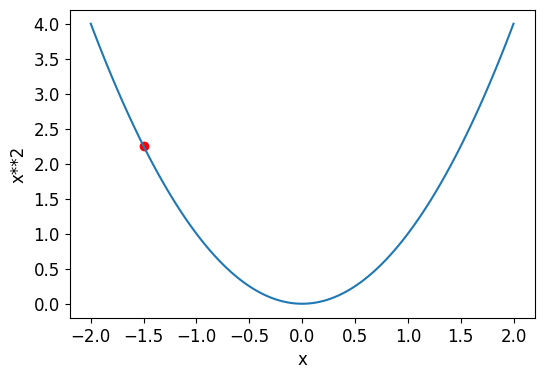

In [294]:
plot_function(f, 'x', 'x**2')
plt.scatter(-1.5, f(-1.5), color='red');

In [295]:
xt = tensor(3.).requires_grad_()


In [296]:
yt = f(xt)
yt

tensor(9., grad_fn=<PowBackward0>)

In [297]:
yt = f(xt)
yt

tensor(9., grad_fn=<PowBackward0>)

In [298]:

yt.backward()

In [299]:
xt.grad

tensor(6.)

If you remember your high school calculus rules, the derivative of x**2 is 2*x, and we have x=3, so the gradients should be 2*3=6, which is what PyTorch calculated for us!

Now we'll repeat the preceding steps, but with a vector argument for our function:

In [300]:
#Now we'll repeat the preceding steps, but with a vector argument for our function:


If you remember your high school calculus rules, the derivative of x**2 is 2*x, and we have x=3, so the gradients should be 2*3=6, which is what PyTorch calculated for us!

Now we'll repeat the preceding steps, but with a vector argument for our function:

In [301]:
xt = tensor([3.,4.,10.]).requires_grad_()
xt

tensor([ 3.,  4., 10.], requires_grad=True)

#tensor(3.) creates a 0  deminsional Pytourch tensor 
#currently holds the value 3.0 and is of type float. The requires_grad_() method is called on the tensor to indicate that we want to compute gradients with respect to this tensor during backpropagation. This is typically used in the context of training neural networks, where we need to compute gradients for optimization purposes.
#Track every operation involving this tensor so I can compute gradients later.
#What this enables

Once requires_grad=True, PyTorch will:
Record every operation involving xt
Build a computation graph
Allow you to call .backward()
Store the gradient in xt.grad

In [302]:
def f(x): return (x**2).sum()

yt = f(xt)
yt

tensor(125., grad_fn=<SumBackward0>)

In [303]:
yt.backward()
xt.grad

tensor([ 6.,  8., 20.])

## Stepping With a Learning Rate

Deciding how to change our parameters based on the values of the gradients is an important part of the deep learning process. Nearly all approaches start with the basic idea of multiplying the gradient by some small number, called the learning rate (LR). The learning rate is often a number between 0.001 and 0.1, although it could be anything. Often, people select a learning rate just by trying a few, and finding which results in the best model after training (we'll show you a better approach later in this book, called the learning rate finder). Once you've picked a learning rate, you can adjust your parameters using this simple function:

We've seen how to use gradients to find a minimum. Now it's time to look at an SGD example and see how finding a minimum can be used to train a model to fit data better.
Let's start with a simple, synthetic, example model. Imagine you were measuring the speed of a roller coaster as it went over the top of a hump. It would start fast, and then get slower as it went up the hill; it would be slowest at the top, and it would then speed up again as it went downhill. You want to build a model of how the speed changes over time. If you were measuring the speed manually every second for 20 seconds, it might look something like this:

In [304]:
time = torch.arange(0,20).float(); time

tensor([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13., 14., 15., 16., 17., 18., 19.])

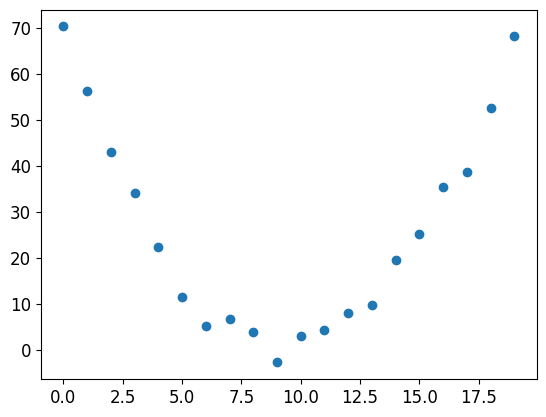

In [305]:
speed = torch.randn(20)*3 + 0.75*(time-9.5)**2 + 1
plt.scatter(time,speed);

This is known as stepping your parameters, using an optimizer step. Notice how we subtract the gradient * lr from the parameter to update it. This allows us to adjust the parameter in the direction of the slope by increasing the parameter when the slope is negative and decreasing the parameter when the slope is positive. We want to adjust our parameters in the direction of the slope because our goal in deep learning is to minimize the loss.

If you pick a learning rate that's too low, it can mean having to do a lot of steps. <> illustrates that.

We've added a bit of random noise, since measuring things manually isn't precise. This means it's not that easy to answer the question: what was the roller coaster's speed? Using SGD we can try to find a function that matches our observations. We can't consider every possible function, so let's use a guess that it will be quadratic; i.e., a function of the form a*(time**2)+(b*time)+c.

We want to distinguish clearly between the function's input (the time when we are measuring the coaster's speed) and its parameters (the values that define which quadratic we're trying). So, let's collect the parameters in one argument and thus separate the input, t, and the parameters, params, in the function's signature:

We need to define first what we mean by "best." We define this precisely by choosing a loss function, which will return a value based on a prediction and a target, where lower values of the function correspond to "better" predictions. It is important for loss functions to return lower values when predictions are more accurate, as the SGD procedure we defined earlier will try to minimize this loss. For continuous data, it's common to use mean squared error:

In [306]:
def f(t, params):
    a,b,c = params
    return a*(t**2) + (b*t) + c

In [307]:
def mse(preds, targets): return ((preds-targets)**2).mean()

lets walk through the 7  step  Process :


Step 1: Initialize the parameters
First, we initialize the parameters to random values, and tell PyTorch that we want to track their gradients, using requires_grad_

In [308]:
params = torch.randn(3).requires_grad_()

In [309]:
#hide
orig_params = params.clone()

Step 2: Calculate the predictions

In [310]:
preds = f(time, params)

Let's create a little function to see how close our predictions are to our targets, and take a look:

In [311]:

def show_preds(preds, ax=None):
    if ax is None: ax=plt.subplots()[1]
    ax.scatter(time, speed)
    ax.scatter(time, to_np(preds), color='red')
    ax.set_ylim(-300,100)

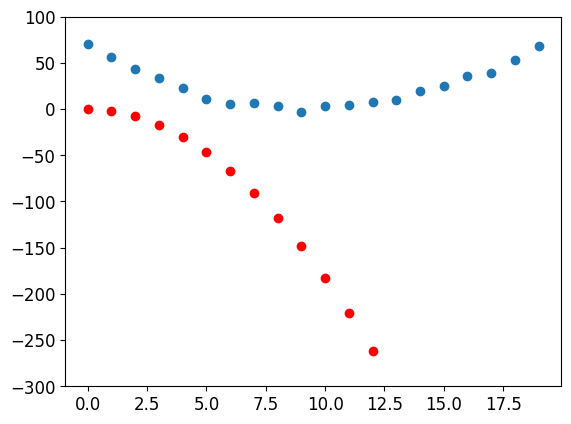

In [312]:
show_preds(preds)

This doesn't look very close—our random parameters suggest that the roller coaster will end up going backwards, since we have negative speeds!

In [313]:
loss = mse(preds, speed)
loss

tensor(107321., grad_fn=<MeanBackward0>)

Our goal is now to improve this. To do that, we'll need to know the gradients.

step  4 :   Calculate the gradients
To calculate the gradients, we need to calculate the loss, and then call backward on it:

In [314]:
loss.backward()
params.grad

tensor([-109574.1250,   -7033.9238,    -500.0884])

In [315]:
params.grad * 1e-5

tensor([-1.0957, -0.0703, -0.0050])

We can use these gradients to improve our parameters. We'll need to pick a learning rate (we'll discuss how to do that in practice in the next chapter; for now we'll just use 1e-5, or 0.00001):

In [316]:
params

tensor([-1.7777, -0.5516,  0.4564], requires_grad=True)

Step 5: Step the weights.

Now we need to update the parameters based on the gradients we just calculated:

In [317]:
lr = 1e-5
params.data -= lr * params.grad.data
params.grad = None

a: Understanding this bit depends on remembering recent history. To calculate the gradients we call backward on the loss. But this loss was itself calculated by mse, which in turn took preds as an input, which was calculated using f taking as an input params, which was the object on which we originally called requires_grad_—which is the original call that now allows us to call backward on loss. This chain of function calls represents the mathematical composition of functions, which enables PyTorch to use calculus's chain rule under the hood to calculate these gradients.

Let's see if the loss has improved:

In [318]:
preds = f(time,params)
mse(preds, speed)

tensor(20817.2871, grad_fn=<MeanBackward0>)

And take a look at the plot:

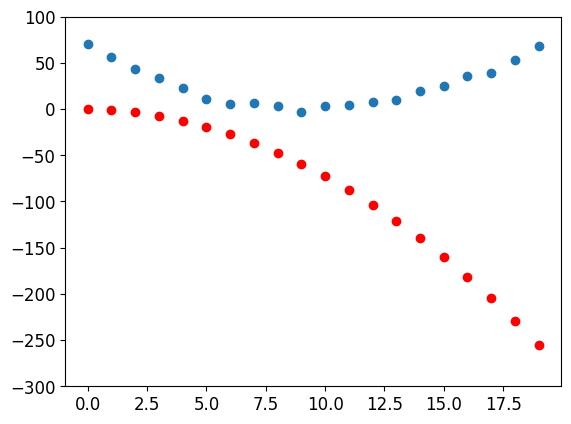

In [319]:
show_preds(preds)

We need to repeat this a few times, so we'll create a function to apply one step:

In [320]:
def apply_step(params, prn=True):
    preds = f(time, params)
    loss = mse(preds, speed)
    loss.backward()
    params.data -= lr * params.grad.data
    params.grad = None
    if prn: print(loss.item())
    return preds

Step 6: Repeat the process:

Now we iterate. By looping and performing many improvements, we hope to reach a good result:

In [321]:
for i in range(10): apply_step(params)

20817.287109375
4448.14453125
1350.5999755859375
764.4468994140625
653.5260009765625
632.5335693359375
628.5582885742188
627.8031616210938
627.6574096679688
627.6270141601562


In [322]:
params = orig_params.detach().requires_grad_()

The loss is going down, just as we hoped! But looking only at these loss numbers disguises the fact that each iteration represents an entirely different quadratic function being tried, on the way to finding the best possible quadratic function. We can see this process visually if, instead of printing out the loss function, we plot the function at every step. Then we can see how the shape is approaching the best possible quadratic function for our data

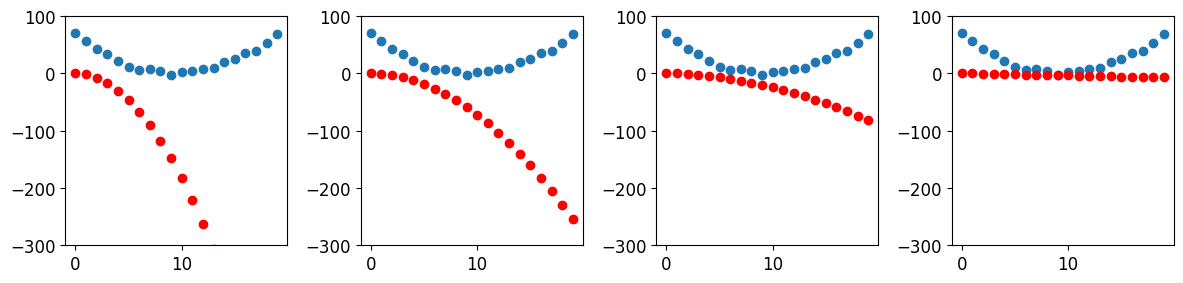

In [323]:
_,axs = plt.subplots(1,4,figsize=(12,3))
for ax in axs: show_preds(apply_step(params, False), ax)
plt.tight_layout()

Step 7: stop

We just decided to stop after 10 epochs arbitrarily. In practice, we would watch the training and validation losses and our metrics to decide when to stop, as we've discussed.

## Summarizing Gradient Descent

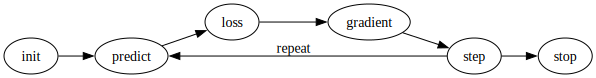

In [324]:
#hide_input
#id gradient_descent
#caption The gradient descent process
#alt Graph showing the steps for Gradient Descent
gv('''
init->predict->loss->gradient->step->stop
step->predict[label=repeat]
''')

To summarize, at the beginning, the weights of our model can be random (training from scratch) or come from a pretrained model (transfer learning). In the first case, the output we will get from our inputs won't have anything to do with what we want, and even in the second case, it's very likely the pretrained model won't be very good at the specific task we are targeting. So the model will need to learn better weights.

We begin by comparing the outputs the model gives us with our targets (we have labeled data, so we know what result the model should give) using a loss function, which returns a number that we want to make as low as possible by improving our weights. To do this, we take a few data items (such as images) from the training set and feed them to our model. We compare the corresponding targets using our loss function, and the score we get tells us how wrong our predictions were. We then change the weights a little bit to make it slightly better.

To find how to change the weights to make the loss a bit better, we use calculus to calculate the gradients. (Actually, we let PyTorch do it for us!) Let's consider an analogy. Imagine you are lost in the mountains with your car parked at the lowest point. To find your way back to it, you might wander in a random direction, but that probably wouldn't help much. Since you know your vehicle is at the lowest point, you would be better off going downhill. By always taking a step in the direction of the steepest downward slope, you should eventually arrive at your destination. We use the magnitude of the gradient (i.e., the steepness of the slope) to tell us how big a step to take; specifically, we multiply the gradient by a number we choose called the learning rate to decide on the step size. We then iterate until we have reached the lowest point, which will be our parking lot, then we can stop.

All of that we just saw can be transposed directly to the MNIST dataset, except for the loss function. Let's now see how we can define a good training objective.

###  The MNIST Loss Function

We already have our independent variables x—these are the images themselves. We'll concatenate them all into a single tensor, and also change them from a list of matrices (a rank-3 tensor) to a list of vectors (a rank-2 tensor). We can do this using view, which is a PyTorch method that changes the shape of a tensor without changing its contents. -1 is a special parameter to view that means "make this axis as big as necessary to fit all the data":

In [325]:
train_x = torch.cat([stacked_threes, stacked_sevens]).view(-1, 28*28)

We need a label for each image. We'll use 1 for 3s and 0 for 7s:

In [326]:
train_y = tensor([1]*len(threes) + [0]*len(sevens)).unsqueeze(1)
train_x.shape,train_y.shape

(torch.Size([12396, 784]), torch.Size([12396, 1]))

A Dataset in PyTorch is required to return a tuple of (x,y) when indexed. Python provides a zip function which, when combined with list, provides a simple way to get this functionality:

In [327]:
dset = list(zip(train_x,train_y))
x,y = dset[0]
x.shape,y

(torch.Size([784]), tensor([1]))

In [328]:
valid_x = torch.cat([valid_3_tens, valid_7_tens]).view(-1, 28*28)
valid_y = tensor([1]*len(valid_3_tens) + [0]*len(valid_7_tens)).unsqueeze(1)
valid_dset = list(zip(valid_x,valid_y))

Now we need an (initially random) weight for every pixel (this is the initialize step in our seven-step process):

In [329]:
def init_params(size, std=1.0): return (torch.randn(size)*std).requires_grad_()

In [330]:
weights = init_params((28*28,1))

The function weights*pixels won't be flexible enough—it is always equal to 0 when the pixels are equal to 0 (i.e., its intercept is 0). You might remember from high school math that the formula for a line is y=w*x+b; we still need the b. We'll initialize it to a random number too:

In [331]:
bias = init_params(1)

jargon: Parameters: The weights and biases of a model. The weights are the w in the equation w*x+b, and the biases are the b in that equation.

We can now calculate a prediction for one image:

In [332]:
(train_x[0]*weights.T).sum() + bias

tensor([14.6918], grad_fn=<AddBackward0>)

While we could use a Python for loop to calculate the prediction for each image, that would be very slow. Because Python loops don't run on the GPU, and because Python is a slow language for loops in general, we need to represent as much of the computation in a model as possible using higher-level functions.

In this case, there's an extremely convenient mathematical operation that calculates w*x for every row of a matrix—it's called matrix multiplication. <> shows what matrix multiplication looks like.

This image shows two matrices, A and B, being multiplied together. Each item of the result, which we'll call AB, contains each item of its corresponding row of A multiplied by each item of its corresponding column of B, added together. For instance, row 1, column 2 (the yellow dot with a red border) is calculated as  𝑎1,1∗𝑏1,2+𝑎1,2∗𝑏2,2 . If you need a refresher on matrix multiplication, we suggest you take a look at the Intro to Matrix Multiplication on Khan Academy, since this is the most important mathematical operation in deep learning.

In Python, matrix multiplication is represented with the @ operator. Let's try it:

In [333]:
def linear1(xb): return xb@weights + bias
preds = linear1(train_x)
preds

tensor([[14.6918],
        [11.8750],
        [ 5.2761],
        ...,
        [12.8740],
        [13.4827],
        [ 8.1398]], grad_fn=<AddBackward0>)

The first element is the same as we calculated before, as we'd expect. This equation, batch@weights + bias, is one of the two fundamental equations of any neural network (the other one is the activation function, which we'll see in a moment).

Let's check our accuracy. To decide if an output represents a 3 or a 7, we can just check whether it's greater than 0.0, so our accuracy for each item can be calculated (using broadcasting, so no loops!) with:

In [334]:
corrects = (preds>0.0).float() == train_y
corrects

tensor([[ True],
        [ True],
        [ True],
        ...,
        [False],
        [False],
        [False]])

In [335]:
corrects.float().mean().item()

0.4435301721096039

Now let's see what the change in accuracy is for a small change in one of the weights (note that we have to ask PyTorch not to calculate gradients as we do this, which is what with torch.no_grad() is doing here):

In [336]:
with torch.no_grad(): weights[0] *= 1.0001

In [337]:
preds = linear1(train_x)
((preds>0.0).float() == train_y).float().mean().item()

0.4435301721096039

As we've seen, we need gradients in order to improve our model using SGD, and in order to calculate gradients we need some loss function that represents how good our model is. That is because the gradients are a measure of how that loss function changes with small tweaks to the weights.

So, we need to choose a loss function. The obvious approach would be to use accuracy, which is our metric, as our loss function as well. In this case, we would calculate our prediction for each image, collect these values to calculate an overall accuracy, and then calculate the gradients of each weight with respect to that overall accuracy.

Unfortunately, we have a significant technical problem here. The gradient of a function is its slope, or its steepness, which can be defined as rise over run—that is, how much the value of the function goes up or down, divided by how much we changed the input. We can write this in mathematically as: (y_new - y_old) / (x_new - x_old). This gives us a good approximation of the gradient when x_new is very similar to x_old, meaning that their difference is very small. But accuracy only changes at all when a prediction changes from a 3 to a 7, or vice versa. The problem is that a small change in weights from x_old to x_new isn't likely to cause any prediction to change, so (y_new - y_old) will almost always be 0. In other words, the gradient is 0 almost everywhere.

A very small change in the value of a weight will often not actually change the accuracy at all. This means it is not useful to use accuracy as a loss function—if we do, most of the time our gradients will actually be 0, and the model will not be able to learn from that number.

S: In mathematical terms, accuracy is a function that is constant almost everywhere (except at the threshold, 0.5), so its derivative is nil almost everywhere (and infinity at the threshold). This then gives gradients that are 0 or infinite, which are useless for updating the model.

Instead, we need a loss function which, when our weights result in slightly better predictions, gives us a slightly better loss. So what does a "slightly better prediction" look like, exactly? Well, in this case, it means that if the correct answer is a 3 the score is a little higher, or if the correct answer is a 7 the score is a little lower.

Let's write such a function now. What form does it take?

The loss function receives not the images themselves, but the predictions from the model. Let's make one argument, prds, of values between 0 and 1, where each value is the prediction that an image is a 3. It is a vector (i.e., a rank-1 tensor), indexed over the images.

The purpose of the loss function is to measure the difference between predicted values and the true values — that is, the targets (aka labels). Let's make another argument, trgts, with values of 0 or 1 which tells whether an image actually is a 3 or not. It is also a vector (i.e., another rank-1 tensor), indexed over the images.

So, for instance, suppose we had three images which we knew were a 3, a 7, and a 3. And suppose our model predicted with high confidence (0.9) that the first was a 3, with slight confidence (0.4) that the second was a 7, and with fair confidence (0.2), but incorrectly, that the last was a 7. This would mean our loss function would receive these values as its inputs:

In [338]:
trgts  = tensor([1,0,1])
prds   = tensor([0.9, 0.4, 0.2])

Here's a first try at a loss function that measures the distance between predictions and targets:

In [339]:
def mnist_loss(predictions, targets):
    return torch.where(targets==1, 1-predictions, predictions).mean()

We're using a new function, torch.where(a,b,c). This is the same as running the list comprehension [b[i] if a[i] else c[i] for i in range(len(a))], except it works on tensors, at C/CUDA speed. In plain English, this function will measure how distant each prediction is from 1 if it should be 1, and how distant it is from 0 if it should be 0, and then it will take the mean of all those distances.

note: Read the Docs: It's important to learn about PyTorch functions like this, because looping over tensors in Python performs at Python speed, not C/CUDA speed! Try running help(torch.where) now to read the docs for this function, or, better still, look it up on the PyTorch documentation site.

Let's try it on our prds and trgts:

In [340]:
torch.where(trgts==1, 1-prds, prds)

tensor([0.1000, 0.4000, 0.8000])

You can see that this function returns a lower number when predictions are more accurate, when accurate predictions are more confident (higher absolute values), and when inaccurate predictions are less confident. In PyTorch, we always assume that a lower value of a loss function is better. Since we need a scalar for the final loss, mnist_loss takes the mean of the previous tensor:

In [341]:
mnist_loss(prds,trgts)

tensor(0.4333)

For instance, if we change our prediction for the one "false" target from 0.2 to 0.8 the loss will go down, indicating that this is a better prediction:

In [342]:
mnist_loss(tensor([0.9, 0.4, 0.8]),trgts)

tensor(0.2333)

One problem with mnist_loss as currently defined is that it assumes that predictions are always between 0 and 1. We need to ensure, then, that this is actually the case! As it happens, there is a function that does exactly that—let's take a look.

Sigmoid

The sigmoid function always outputs a number between 0 and 1. It's defined as follows:

In [343]:
def sigmoid(x): return 1/(1+torch.exp(-x))

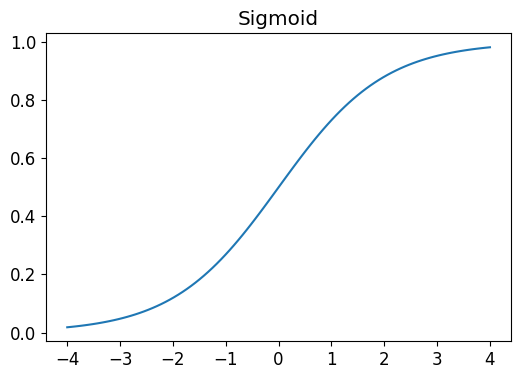

In [344]:
plot_function(torch.sigmoid, title='Sigmoid', min=-4, max=4)

As you can see, it takes any input value, positive or negative, and smooshes it onto an output value between 0 and 1. It's also a smooth curve that only goes up, which makes it easier for SGD to find meaningful gradients.

Let's update mnist_loss to first apply sigmoid to the inputs:

In [345]:
def mnist_loss(predictions, targets):
    predictions = predictions.sigmoid()
    return torch.where(targets==1, 1-predictions, predictions).mean()

Now we can be confident our loss function will work, even if the predictions are not between 0 and 1. All that is required is that a higher prediction corresponds to higher confidence an image is a 3.

Having defined a loss function, now is a good moment to recapitulate why we did this. After all, we already had a metric, which was overall accuracy. So why did we define a loss?

The key difference is that the metric is to drive human understanding and the loss is to drive automated learning. To drive automated learning, the loss must be a function that has a meaningful derivative. It can't have big flat sections and large jumps, but instead must be reasonably smooth. This is why we designed a loss function that would respond to small changes in confidence level. This requirement means that sometimes it does not really reflect exactly what we are trying to achieve, but is rather a compromise between our real goal and a function that can be optimized using its gradient. The loss function is calculated for each item in our dataset, and then at the end of an epoch the loss values are all averaged and the overall mean is reported for the epoch.

Metrics, on the other hand, are the numbers that we really care about. These are the values that are printed at the end of each epoch that tell us how our model is really doing. It is important that we learn to focus on these metrics, rather than the loss, when judging the performance of a model.

Now that we have a loss function that is suitable for driving SGD, we can consider some of the details involved in the next phase of the learning process, which is to change or update the weights based on the gradients. This is called an optimization step.

In order to take an optimization step we need to calculate the loss over one or more data items. How many should we use? We could calculate it for the whole dataset, and take the average, or we could calculate it for a single data item. But neither of these is ideal. Calculating it for the whole dataset would take a very long time. Calculating it for a single item would not use much information, so it would result in a very imprecise and unstable gradient. That is, you'd be going to the trouble of updating the weights, but taking into account only how that would improve the model's performance on that single item.
## SGD and Mini-Batches
So instead we take a compromise between the two: we calculate the average loss for a few data items at a time. This is called a mini-batch. The number of data items in the mini-batch is called the batch size. A larger batch size means that you will get a more accurate and stable estimate of your dataset's gradients from the loss function, but it will take longer, and you will process fewer mini-batches per epoch. Choosing a good batch size is one of the decisions you need to make as a deep learning practitioner to train your model quickly and accurately. We will talk about how to make this choice throughout this book.

Another good reason for using mini-batches rather than calculating the gradient on individual data items is that, in practice, we nearly always do our training on an accelerator such as a GPU. These accelerators only perform well if they have lots of work to do at a time, so it's helpful if we can give them lots of data items to work on. Using mini-batches is one of the best ways to do this. However, if you give them too much data to work on at once, they run out of memory—making GPUs happy is also tricky!

As we saw in our discussion of data augmentation in <>, we get better generalization if we can vary things during training. One simple and effective thing we can vary is what data items we put in each mini-batch. Rather than simply enumerating our dataset in order for every epoch, instead what we normally do is randomly shuffle it on every epoch, before we create mini-batches. PyTorch and fastai provide a class that will do the shuffling and mini-batch collation for you, called DataLoader.

A DataLoader can take any Python collection and turn it into an iterator over mini-batches, like so:

In [346]:
coll = range(15)
dl = DataLoader(coll, batch_size=5, shuffle=True)
list(dl)

[tensor([10, 12,  9, 14,  2]),
 tensor([ 3,  4,  6, 13,  7]),
 tensor([ 8, 11,  0,  5,  1])]

For training a model, we don't just want any Python collection, but a collection containing independent and dependent variables (that is, the inputs and targets of the model). A collection that contains tuples of independent and dependent variables is known in PyTorch as a Dataset. Here's an example of an extremely simple Dataset:

In [347]:
ds = L(enumerate(string.ascii_lowercase))
ds

[(0, 'a'), (1, 'b'), (2, 'c'), (3, 'd'), (4, 'e'), (5, 'f'), (6, 'g'), (7, 'h'), (8, 'i'), (9, 'j'), (10, 'k'), (11, 'l'), (12, 'm'), (13, 'n'), (14, 'o'), (15, 'p'), (16, 'q'), (17, 'r'), (18, 's'), (19, 't'), (20, 'u'), (21, 'v'), (22, 'w'), (23, 'x'), (24, 'y'), (25, 'z')]


When we pass a Dataset to a DataLoader we will get back mini-batches which are themselves tuples of tensors representing batches of independent and dependent variables:

In [348]:
dl = DataLoader(ds, batch_size=6, shuffle=True)
list(dl)

[(tensor([ 5,  9,  8, 15,  4, 24]), ('f', 'j', 'i', 'p', 'e', 'y')),
 (tensor([ 0, 18, 12, 10,  6, 20]), ('a', 's', 'm', 'k', 'g', 'u')),
 (tensor([17, 16, 23, 13,  3, 14]), ('r', 'q', 'x', 'n', 'd', 'o')),
 (tensor([21, 22,  7, 19,  1,  2]), ('v', 'w', 'h', 't', 'b', 'c')),
 (tensor([11, 25]), ('l', 'z'))]

### We are now ready to write our first training loop for a model using SGD!

### Putting It All Together

It's time to implement the process we saw in <>. In code, our process will be implemented something like this for each epoch:
for x,y in dl:
    pred = model(x)
    loss = loss_func(pred, y)
    loss.backward()
    parameters -= parameters.grad * lr

First, let's re-initialize our parameters:

In [349]:
weights = init_params((28*28,1))
bias = init_params(1)

A DataLoader can be created from a Dataset:

In [350]:
dl = DataLoader(dset, batch_size=256)
xb,yb = first(dl)
xb.shape,yb.shape

(torch.Size([256, 784]), torch.Size([256, 1]))

We'll do the same for the validation set:

In [351]:
valid_dl = DataLoader(valid_dset, batch_size=256)

Let's create a mini-batch of size 4 for testing:

In [352]:
batch = train_x[:4]
batch.shape

torch.Size([4, 784])

In [353]:
preds = linear1(batch)
preds

tensor([[ 4.6331],
        [ 0.9992],
        [-0.9396],
        [-2.9143]], grad_fn=<AddBackward0>)

In [354]:
loss = mnist_loss(preds, train_y[:4])
loss

tensor(0.4866, grad_fn=<MeanBackward0>)

Now we can calculate the gradients:

In [355]:
loss.backward()
weights.grad.shape,weights.grad.mean(),bias.grad

(torch.Size([784, 1]), tensor(-0.0167), tensor([-0.1143]))

Let's put that all in a function:

In [356]:
def calc_grad(xb, yb, model):
    preds = model(xb)
    loss = mnist_loss(preds, yb)
    loss.backward()

and test it:

In [357]:
calc_grad(batch, train_y[:4], linear1)
weights.grad.mean(),bias.grad

(tensor(-0.0335), tensor([-0.2285]))

In [358]:
calc_grad(batch, train_y[:4], linear1)
weights.grad.mean(),bias.grad

(tensor(-0.0502), tensor([-0.3428]))

The gradients have changed! The reason for this is that loss.backward actually adds the gradients of loss to any gradients that are currently stored. So, we have to set the current gradients to 0 first:

In [359]:
weights.grad.zero_()
bias.grad.zero_();

Note: Inplace Operations: Methods in PyTorch whose names end in an underscore modify their objects in place. For instance, bias.zero_() sets all elements of the tensor bias to 0.

Our only remaining step is to update the weights and biases based on the gradient and learning rate. When we do so, we have to tell PyTorch not to take the gradient of this step too—otherwise things will get very confusing when we try to compute the derivative at the next batch! If we assign to the data attribute of a tensor then PyTorch will not take the gradient of that step. Here's our basic training loop for an epoch:

In [360]:
def train_epoch(model, lr, params):
    for xb,yb in dl:
        calc_grad(xb, yb, model)
        for p in params:
            p.data -= p.grad*lr
            p.grad.zero_()

We also want to check how we're doing, by looking at the accuracy of the validation set. To decide if an output represents a 3 or a 7, we can just check whether it's greater than 0. So our accuracy for each item can be calculated (using broadcasting, so no loops!) with:

In [361]:
(preds>0.0).float() == train_y[:4]

tensor([[ True],
        [ True],
        [False],
        [False]])

That gives us this function to calculate our validation accuracy:

In [362]:
def batch_accuracy(xb, yb):
    preds = xb.sigmoid()
    correct = (preds>0.5) == yb
    return correct.float().mean()

We can check it works:

In [363]:
batch_accuracy(linear1(batch), train_y[:4])

tensor(0.5000)

In [364]:
def validate_epoch(model):
    accs = [batch_accuracy(model(xb), yb) for xb,yb in valid_dl]
    return round(torch.stack(accs).mean().item(), 4)

In [365]:
validate_epoch(linear1)

0.3759

That's our starting point. Let's train for one epoch, and see if the accuracy improves:

In [366]:
lr = 1.
params = weights,bias
train_epoch(linear1, lr, params)
validate_epoch(linear1)

0.4937

In [367]:
# Then do a few more:

In [368]:
for i in range(20):
    train_epoch(linear1, lr, params)
    print(validate_epoch(linear1), end=' ')

0.61 0.6015 0.832 0.9247 0.9462 0.9545 0.9589 0.9609 0.9647 0.9652 0.9667 0.9682 0.9691 0.9701 0.9716 0.9726 0.974 0.975 0.9755 0.9755 

Looking good! We're already about at the same accuracy as our "pixel similarity" approach, and we've created a general-purpose foundation we can build on. Our next step will be to create an object that will handle the SGD step for us. In PyTorch, it's called an *optimizer*.

Creating an Optimizer

Because this is such a general foundation, PyTorch provides some useful classes to make it easier to implement. The first thing we can do is replace our linear1 function with PyTorch's nn.Linear module. A module is an object of a class that inherits from the PyTorch nn.Module class. Objects of this class behave identically to standard Python functions, in that you can call them using parentheses and they will return the activations of a model.

nn.Linear does the same thing as our init_params and linear together. It contains both the weights and biases in a single class. Here's how we replicate our model from the previous section:

In [369]:
linear_model = nn.Linear(28*28,1)

Every PyTorch module knows what parameters it has that can be trained; they are available through the parameters method:

In [370]:
w,b = linear_model.parameters()
w.shape,b.shape

(torch.Size([1, 784]), torch.Size([1]))

We can use this information to create an optimizer:

In [371]:
class BasicOptim:
    def __init__(self,params,lr): self.params,self.lr = list(params),lr

    def step(self, *args, **kwargs):
        for p in self.params: p.data -= p.grad.data * self.lr

    def zero_grad(self, *args, **kwargs):
        for p in self.params: p.grad = None

We can create our optimizer by passing in the model's parameters:

In [372]:
opt = BasicOptim(linear_model.parameters(), lr)

Our training loop can now be simplified to:

In [373]:
def train_epoch(model):
    for xb,yb in dl:
        calc_grad(xb, yb, model)
        opt.step()
        opt.zero_grad()

In [374]:
validate_epoch(linear_model)

0.5011

Let's put our little training loop in a function, to make things simpler:

In [375]:
def train_model(model, epochs):
    for i in range(epochs):
        train_epoch(model)
        print(validate_epoch(model), end=' ')

The results are the same as in the previous section:

In [376]:
train_model(linear_model, 20)

0.4932 0.8388 0.8423 0.9131 0.9336 0.9487 0.9555 0.9629 0.9658 0.9668 0.9697 0.9717 0.9746 0.9751 0.9761 0.977 0.9775 0.978 0.9785 0.979 

fastai provides the SGD class which, by default, does the same thing as our BasicOptim:

In [377]:
linear_model = nn.Linear(28*28,1)
opt = SGD(linear_model.parameters(), lr)
train_model(linear_model, 20)

0.4932 0.9425 0.7339 0.8911 0.9233 0.9404 0.9526 0.9604 0.9648 0.9658 0.9687 0.9702 0.9726 0.9741 0.9751 0.9761 0.977 0.9775 0.978 0.9785 

fastai also provides Learner.fit, which we can use instead of train_model. To create a Learner we first need to create a DataLoaders, by passing in our training and validation DataLoaders:

In [378]:
dls = DataLoaders(dl, valid_dl)

To create a Learner without using an application (such as vision_learner) we need to pass in all the elements that we've created in this chapter: the DataLoaders, the model, the optimization function (which will be passed the parameters), the loss function, and optionally any metrics to print:

In [379]:
learn = Learner(dls, nn.Linear(28*28,1), opt_func=SGD,
                loss_func=mnist_loss, metrics=batch_accuracy)

In [390]:
learn.fit(10, lr=lr)

epoch,train_loss,valid_loss,batch_accuracy,time
0,0.007366,0.144014,0.863592,00:00
1,0.010572,0.043966,0.957311,00:00
2,0.009475,0.041822,0.959764,00:00
3,0.008829,0.040281,0.961236,00:00
4,0.008381,0.038913,0.962709,00:00
5,0.008062,0.037456,0.964181,00:00
6,0.007824,0.035971,0.965162,00:00
7,0.007644,0.034543,0.965653,00:00
8,0.007512,0.033161,0.968106,00:00
9,0.007427,0.031743,0.970069,00:00


So far we have a general procedure for optimizing the parameters of a function, and we have tried it out on a very boring function: a simple linear classifier. A linear classifier is very constrained in terms of what it can do. To make it a bit more complex (and able to handle more tasks), we need to add something nonlinear between two linear classifiers—this is what gives us a neural network.

Here is the entire definition of a basic neural network:

In [391]:
def simple_net(xb): 
    res = xb@w1 + b1
    res = res.max(tensor(0.0))
    res = res@w2 + b2
    return res

That's it! All we have in simple_net is two linear classifiers with a max function between them.

Here, w1 and w2 are weight tensors, and b1 and b2 are bias tensors; that is, parameters that are initially randomly initialized, just like we did in the previous section:

In [382]:
w1 = init_params((28*28,30))
b1 = init_params(30)
w2 = init_params((30,1))
b2 = init_params(1)

The key point about this is that w1 has 30 output activations (which means that w2 must have 30 input activations, so they match). That means that the first layer can construct 30 different features, each representing some different mix of pixels. You can change that 30 to anything you like, to make the model more or less complex.

That little function res.max(tensor(0.0)) is called a rectified linear unit, also known as ReLU. We think we can all agree that rectified linear unit sounds pretty fancy and complicated... But actually, there's nothing more to it than res.max(tensor(0.0))—in other words, replace every negative number with a zero. This tiny function is also available in PyTorch as F.relu:

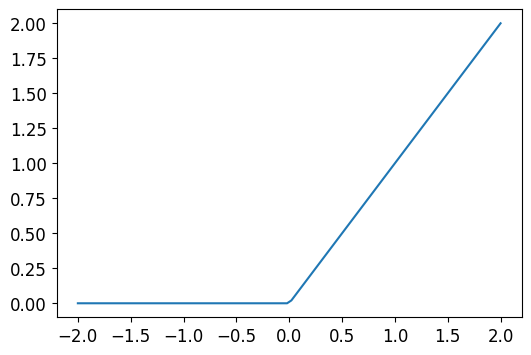

In [392]:
plot_function(F.relu)

There is an enormous amount of jargon in deep learning, including terms like rectified linear unit. The vast vast majority of this jargon is no more complicated than can be implemented in a short line of code, as we saw in this example. The reality is that for academics to get their papers published they need to make them sound as impressive and sophisticated as possible. One of the ways that they do that is to introduce jargon. Unfortunately, this has the result that the field ends up becoming far more intimidating and difficult to get into than it should be. You do have to learn the jargon, because otherwise papers and tutorials are not going to mean much to you. But that doesn't mean you have to find the jargon intimidating. Just remember, when you come across a word or phrase that you haven't seen before, it will almost certainly turn out to be referring to a very simple concept.

In [384]:
simple_net = nn.Sequential(
    nn.Linear(28*28,30),
    nn.ReLU(),
    nn.Linear(30,1)
)

In [385]:
learn = Learner(dls, simple_net, opt_func=SGD,
                loss_func=mnist_loss, metrics=batch_accuracy)

In [395]:
#hide_output
learn.fit(40, 0.1)

epoch,train_loss,valid_loss,batch_accuracy,time
0,0.016727,0.019860,0.981845,00:00
1,0.013875,0.018753,0.982336,00:00
2,0.012687,0.018680,0.981845,00:00
3,0.012174,0.018697,0.982826,00:00
4,0.011921,0.018699,0.982826,00:00
5,0.011772,0.018683,0.982826,00:00
6,0.011666,0.018652,0.982826,00:00
7,0.011579,0.018613,0.982826,00:00
8,0.011502,0.018567,0.982826,00:00
9,0.011431,0.018516,0.982826,00:00


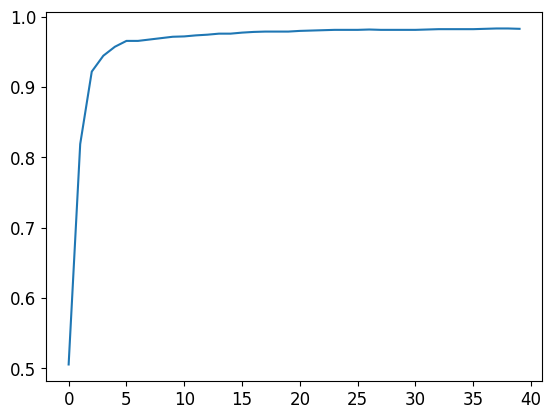

In [387]:
plt.plot(L(learn.recorder.values).itemgot(2));

In [388]:
learn.recorder.values[-1][2]

0.982826292514801

Questionieries 
1. How is a grayscale image represented on a computer? How about a color image?
2. How are the files and folders in the `MNIST_SAMPLE` dataset structured? Why?
3. Explain how the "pixel similarity" approach to classifying digits works.
4. What is a list comprehension? Create one now that selects odd numbers from a list and doubles them.
5. What is a "rank-3 tensor"?
6. What is the difference between tensor rank and shape? How do you get the rank from the shape?
7. What are RMSE and L1 norm?
8. How can you apply a calculation on thousands of numbers at once, many thousands of times faster than a Python loop?
9. Create a 3×3 tensor or array containing the numbers from 1 to 9. Double it. Select the bottom-right four numbers.
10. What is broadcasting?
11. Are metrics generally calculated using the training set, or the validation set? Why?
12. What is SGD?
13. Why does SGD use mini-batches?
14. What are the seven steps in SGD for machine learning?
15. How do we initialize the weights in a model?
16. What is "loss"?
17. Why can't we always use a high learning rate?
18. What is a "gradient"?
19. Do you need to know how to calculate gradients yourself?
20. Why can't we use accuracy as a loss function?
21. Draw the sigmoid function. What is special about its shape?
22. What is the difference between a loss function and a metric?
23. What is the function to calculate new weights using a learning rate?
24. What does the `DataLoader` class do?
25. Write pseudocode showing the basic steps taken in each epoch for SGD.
26. Create a function that, if passed two arguments `[1,2,3,4]` and `'abcd'`, returns `[(1, 'a'), (2, 'b'), (3, 'c'), (4, 'd')]`. What is special about that output data structure?
27. What does `view` do in PyTorch?
28. What are the "bias" parameters in a neural network? Why do we need them?
29. What does the `@` operator do in Python?
30. What does the `backward` method do?
31. Why do we have to zero the gradients?
32. What information do we have to pass to `Learner`?
33. Show Python or pseudocode for the basic steps of a training loop.
34. What is "ReLU"? Draw a plot of it for values from `-2` to `+2`.
35. What is an "activation function"?
36. What's the difference between `F.relu` and `nn.ReLU`?
37. The universal approximation theorem shows that any function can be approximated as closely as needed using just one nonlinearity. So why do we normally use more?

Create your own implementation of Learner from scratch, based on the training loop shown in this chapter.
Complete all the steps in this chapter using the full MNIST datasets (that is, for all digits, not just 3s and 7s). This is a significant project and will take you quite a bit of time to complete! You'll need to do some of your own research to figure out how to overcome some obstacles you'll meet on the way.

## Exercise: Re-implement MNIST 3 vs 7 WITHOUT fastai

In this section we will:
1. Download and preprocess MNIST 3/7 data using only PyTorch (no fastai)
2. Define a linear model and helper functions from scratch
3. Implement a custom training loop with manual SGD
4. Track and visualize gradients during training
5. Evaluate on the validation set

### Step 1: Download and Preprocess MNIST Data (Pure PyTorch)

In [ ]:
# Pure PyTorch imports - NO fastai!
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# Download MNIST dataset using torchvision
transform = transforms.Compose([transforms.ToTensor()])

# Download full MNIST
mnist_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
mnist_test = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

print(f"Training set size: {len(mnist_train)}")
print(f"Test set size: {len(mnist_test)}")

In [ ]:
# Filter for only 3s and 7s
def filter_3_7(dataset):
    """Extract only images labeled 3 or 7"""
    indices = [i for i, (_, label) in enumerate(dataset) if label in [3, 7]]
    images = torch.stack([dataset[i][0] for i in indices])
    labels = torch.tensor([1.0 if dataset[i][1] == 3 else 0.0 for i in indices])
    return images, labels

# Get training data for 3s and 7s
train_images, train_labels = filter_3_7(mnist_train)
test_images, test_labels = filter_3_7(mnist_test)

print(f"Training 3s and 7s: {len(train_labels)}")
print(f"Test 3s and 7s: {len(test_labels)}")
print(f"Image shape: {train_images[0].shape}")

# Flatten images: (N, 1, 28, 28) -> (N, 784)
train_x = train_images.view(-1, 28*28)
train_y = train_labels.unsqueeze(1)
test_x = test_images.view(-1, 28*28)
test_y = test_labels.unsqueeze(1)

print(f"\nFlattened shapes:")
print(f"train_x: {train_x.shape}, train_y: {train_y.shape}")
print(f"test_x: {test_x.shape}, test_y: {test_y.shape}")

### Step 2: Define Model and Helper Functions (Pure PyTorch)

In [ ]:
# Initialize parameters with requires_grad for automatic differentiation
def init_params(size, std=1.0):
    """Initialize random parameters with gradient tracking"""
    return (torch.randn(size) * std).requires_grad_()

# Initialize weights and bias for linear model
# Linear model: y = x @ weights + bias
weights_manual = init_params((28*28, 1))
bias_manual = init_params(1)

print(f"Weights shape: {weights_manual.shape}")
print(f"Bias shape: {bias_manual.shape}")

In [ ]:
# Define model and helper functions
def linear_model(xb):
    """Linear model: y = x @ weights + bias"""
    return xb @ weights_manual + bias_manual

def sigmoid(x):
    """Sigmoid activation function"""
    return 1 / (1 + torch.exp(-x))

def mnist_loss_manual(predictions, targets):
    """
    Binary cross-entropy style loss for MNIST 3 vs 7
    - Apply sigmoid to get probabilities
    - Measure distance from correct label
    """
    predictions = sigmoid(predictions)
    return torch.where(targets == 1, 1 - predictions, predictions).mean()

def calc_accuracy(preds, targets):
    """Calculate accuracy: what % of predictions are correct?"""
    probs = sigmoid(preds)
    predicted_labels = (probs > 0.5).float()
    return (predicted_labels == targets).float().mean()

# Test with a small batch
test_preds = linear_model(train_x[:4])
test_loss = mnist_loss_manual(test_preds, train_y[:4])
test_acc = calc_accuracy(test_preds, train_y[:4])
print(f"Test predictions shape: {test_preds.shape}")
print(f"Test loss: {test_loss.item():.4f}")
print(f"Test accuracy: {test_acc.item():.4f}")

### Step 3: Implement Custom Training Loop with Manual SGD

In [ ]:
# Create simple DataLoader without fastai
batch_size = 256

# Create TensorDatasets
train_dataset = TensorDataset(train_x, train_y)
test_dataset = TensorDataset(test_x, test_y)

# Create DataLoaders using PyTorch
train_dl_manual = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dl_manual = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Number of training batches: {len(train_dl_manual)}")
print(f"Number of test batches: {len(test_dl_manual)}")

In [ ]:
# Re-initialize weights for fresh training
weights_manual = init_params((28*28, 1))
bias_manual = init_params(1)

def calc_grad_manual(xb, yb):
    """
    Calculate gradients for a batch:
    1. Forward pass: compute predictions
    2. Compute loss
    3. Backward pass: compute gradients
    """
    preds = xb @ weights_manual + bias_manual
    loss = mnist_loss_manual(preds, yb)
    loss.backward()
    return loss

# Gradient tracking lists for visualization
gradient_history = {
    'weights_grad_mean': [],
    'weights_grad_norm': [],
    'bias_grad': [],
    'loss': [],
    'accuracy': []
}

def train_epoch_manual(learning_rate):
    """
    Train for one epoch with manual SGD:
    1. Zero gradients
    2. Forward pass
    3. Compute loss
    4. Backward pass (compute gradients)
    5. Update parameters: param = param - lr * grad
    """
    epoch_losses = []
    
    for xb, yb in train_dl_manual:
        # Forward pass and compute gradients
        loss = calc_grad_manual(xb, yb)
        epoch_losses.append(loss.item())
        
        # Manual SGD step - update parameters
        with torch.no_grad():
            weights_manual -= learning_rate * weights_manual.grad
            bias_manual -= learning_rate * bias_manual.grad
            
            # Zero gradients for next batch
            weights_manual.grad.zero_()
            bias_manual.grad.zero_()
    
    return np.mean(epoch_losses)

def validate_manual():
    """Calculate validation accuracy"""
    accs = []
    for xb, yb in test_dl_manual:
        preds = xb @ weights_manual + bias_manual
        acc = calc_accuracy(preds, yb)
        accs.append(acc.item())
    return np.mean(accs)

print("Training functions defined!")

### Step 4: Track and Visualize Gradients During Training

In [ ]:
# Re-initialize for training with gradient tracking
weights_manual = init_params((28*28, 1))
bias_manual = init_params(1)

# Reset gradient history
gradient_history = {
    'weights_grad_mean': [],
    'weights_grad_norm': [],
    'bias_grad': [],
    'loss': [],
    'accuracy': []
}

def train_epoch_with_gradient_tracking(learning_rate):
    """
    Train one epoch and record gradient statistics for inspection
    """
    epoch_losses = []
    epoch_weight_grads = []
    epoch_bias_grads = []
    
    for xb, yb in train_dl_manual:
        # Forward pass
        preds = xb @ weights_manual + bias_manual
        loss = mnist_loss_manual(preds, yb)
        epoch_losses.append(loss.item())
        
        # Backward pass - compute gradients
        loss.backward()
        
        # Record gradient statistics BEFORE updating
        epoch_weight_grads.append(weights_manual.grad.abs().mean().item())
        epoch_bias_grads.append(bias_manual.grad.item())
        
        # Manual SGD step
        with torch.no_grad():
            weights_manual -= learning_rate * weights_manual.grad
            bias_manual -= learning_rate * bias_manual.grad
            weights_manual.grad.zero_()
            bias_manual.grad.zero_()
    
    # Record epoch statistics
    gradient_history['weights_grad_mean'].append(np.mean(epoch_weight_grads))
    gradient_history['weights_grad_norm'].append(np.sqrt(np.sum(np.array(epoch_weight_grads)**2)))
    gradient_history['bias_grad'].append(np.mean(epoch_bias_grads))
    gradient_history['loss'].append(np.mean(epoch_losses))
    
    return np.mean(epoch_losses)

# Training loop with gradient tracking
learning_rate = 1.0
num_epochs = 20

print("Starting training with gradient tracking...")
print("="*60)

for epoch in range(num_epochs):
    # Train
    train_loss = train_epoch_with_gradient_tracking(learning_rate)
    
    # Validate
    val_acc = validate_manual()
    gradient_history['accuracy'].append(val_acc)
    
    # Print progress every 5 epochs
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:2d} | Loss: {train_loss:.4f} | Val Acc: {val_acc:.4f} | "
              f"Weight Grad Mean: {gradient_history['weights_grad_mean'][-1]:.6f}")

print("="*60)
print(f"Final validation accuracy: {gradient_history['accuracy'][-1]:.4f}")

In [ ]:
# Visualize gradient statistics over training
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Plot 1: Loss over epochs
axes[0, 0].plot(gradient_history['loss'], 'b-', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training Loss')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Accuracy over epochs
axes[0, 1].plot(gradient_history['accuracy'], 'g-', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Validation Accuracy')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Weight gradient mean over epochs
axes[1, 0].plot(gradient_history['weights_grad_mean'], 'r-', linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Gradient Mean')
axes[1, 0].set_title('Weight Gradients (Mean Absolute)')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Bias gradient over epochs
axes[1, 1].plot(gradient_history['bias_grad'], 'm-', linewidth=2)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Bias Gradient')
axes[1, 1].set_title('Bias Gradients')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Training Metrics and Gradient Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nGradient Analysis Summary:")
print(f"- Initial weight gradient mean: {gradient_history['weights_grad_mean'][0]:.6f}")
print(f"- Final weight gradient mean: {gradient_history['weights_grad_mean'][-1]:.6f}")
print(f"- Gradient reduction: {gradient_history['weights_grad_mean'][0]/gradient_history['weights_grad_mean'][-1]:.2f}x")

### Step 5: Manually Inspect Gradients

Let's manually inspect the gradients by doing a single forward/backward pass and examining the gradient tensors:

In [ ]:
# Manually inspect gradients with a single batch
# Get a small batch for inspection
xb_inspect, yb_inspect = next(iter(train_dl_manual))
xb_inspect = xb_inspect[:8]  # Just 8 samples
yb_inspect = yb_inspect[:8]

# Zero any existing gradients
if weights_manual.grad is not None:
    weights_manual.grad.zero_()
if bias_manual.grad is not None:
    bias_manual.grad.zero_()

# Forward pass
preds_inspect = xb_inspect @ weights_manual + bias_manual
loss_inspect = mnist_loss_manual(preds_inspect, yb_inspect)

print("="*60)
print("MANUAL GRADIENT INSPECTION")
print("="*60)
print(f"\nInput batch shape: {xb_inspect.shape}")
print(f"Predictions shape: {preds_inspect.shape}")
print(f"Loss value: {loss_inspect.item():.6f}")

# Backward pass - this computes gradients
loss_inspect.backward()

print(f"\n--- GRADIENT SHAPES ---")
print(f"Weight gradients shape: {weights_manual.grad.shape}")
print(f"Bias gradient shape: {bias_manual.grad.shape}")

print(f"\n--- GRADIENT STATISTICS ---")
print(f"Weight gradients:")
print(f"  - Mean: {weights_manual.grad.mean().item():.8f}")
print(f"  - Std:  {weights_manual.grad.std().item():.8f}")
print(f"  - Min:  {weights_manual.grad.min().item():.8f}")
print(f"  - Max:  {weights_manual.grad.max().item():.8f}")
print(f"\nBias gradient: {bias_manual.grad.item():.8f}")

# Visualize weight gradients as image (28x28)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Weight gradient visualization
grad_img = weights_manual.grad.view(28, 28).detach().numpy()
im = axes[0].imshow(grad_img, cmap='RdBu', vmin=-grad_img.max(), vmax=grad_img.max())
axes[0].set_title('Weight Gradients (28x28 view)')
axes[0].axis('off')
plt.colorbar(im, ax=axes[0])

# Histogram of gradients
axes[1].hist(weights_manual.grad.detach().numpy().flatten(), bins=50, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Gradient Value')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Weight Gradients')
axes[1].axvline(x=0, color='r', linestyle='--', label='Zero')
axes[1].legend()

plt.tight_layout()
plt.show()

# Zero gradients after inspection
weights_manual.grad.zero_()
bias_manual.grad.zero_()

### Step 6: Test the Model with Sample Images

In [ ]:
# Test with sample images from the test set
def predict_and_show(img_tensor, true_label, idx):
    """Make prediction and display the image"""
    # Flatten the image
    img_flat = img_tensor.view(1, 28*28)
    
    # Predict
    with torch.no_grad():
        pred = img_flat @ weights_manual + bias_manual
        prob_3 = sigmoid(pred).item()
        prob_7 = 1 - prob_3
    
    # Determine prediction
    predicted = "3" if prob_3 > 0.5 else "7"
    actual = "3" if true_label == 1 else "7"
    correct = "✓" if predicted == actual else "✗"
    
    return {
        'image': img_tensor.squeeze().numpy(),
        'predicted': predicted,
        'actual': actual,
        'prob_3': prob_3,
        'prob_7': prob_7,
        'correct': correct
    }

# Get some test samples
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flatten()):
    result = predict_and_show(test_images[i], test_labels[i].item(), i)
    
    ax.imshow(result['image'], cmap='gray')
    color = 'green' if result['correct'] == "✓" else 'red'
    ax.set_title(f"Pred: {result['predicted']} {result['correct']}\n"
                 f"P(3)={result['prob_3']:.2f}, P(7)={result['prob_7']:.2f}",
                 color=color, fontsize=10)
    ax.axis('off')

plt.suptitle('Model Predictions on Test Images (Pure PyTorch, No fastai)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Calculate final test accuracy
final_acc = validate_manual()
print(f"\n{'='*60}")
print(f"FINAL TEST ACCURACY: {final_acc*100:.2f}%")
print(f"{'='*60}")

### Step 7: Upload Your Own Image to Test (Pure PyTorch)

In [ ]:
# Upload widget for testing with your own images (Pure PyTorch)
import ipywidgets as widgets
from IPython.display import display, clear_output
from PIL import Image
import io

# Create output widget to capture results
output_widget = widgets.Output()

# Create file upload widget
uploader_manual = widgets.FileUpload(
    accept='.png,.jpg,.jpeg',
    multiple=False,
    description='Upload Image'
)

# Create a button to trigger prediction
predict_button = widgets.Button(description='Predict!', button_style='success')

def on_predict_click(b):
    with output_widget:
        clear_output()
        
        if not uploader_manual.value:
            print("Please upload an image first!")
            return
        
        try:
            # Get uploaded file
            file_info = list(uploader_manual.value.values())[0]
            print(f"Processing: {file_info['metadata']['name']}")
            
            # Open and preprocess image
            img = Image.open(io.BytesIO(file_info['content']))
            img_gray = img.convert('L').resize((28, 28))
            
            # Convert to tensor and normalize
            img_array = np.array(img_gray)
            img_tensor = torch.tensor(img_array).float() / 255.0
            img_flat = img_tensor.view(1, 28*28)
            
            # Make prediction using our trained model
            with torch.no_grad():
                pred = img_flat @ weights_manual + bias_manual
                prob_3 = sigmoid(pred).item()
                prob_7 = 1 - prob_3
            
            # Display results
            fig, axes = plt.subplots(1, 2, figsize=(10, 4))
            
            # Show processed image
            axes[0].imshow(img_array, cmap='gray')
            axes[0].set_title('Your Image (28x28)')
            axes[0].axis('off')
            
            # Show prediction probabilities as bar chart
            labels = ['3', '7']
            probs = [prob_3, prob_7]
            colors = ['green' if prob_3 > 0.5 else 'gray', 'green' if prob_7 > 0.5 else 'gray']
            axes[1].bar(labels, probs, color=colors, edgecolor='black')
            axes[1].set_ylim(0, 1)
            axes[1].set_ylabel('Probability')
            axes[1].set_title('Prediction Probabilities')
            
            plt.tight_layout()
            plt.show()
            
            # Print prediction
            predicted = "3" if prob_3 > 0.5 else "7"
            print(f"\n{'='*40}")
            print(f"PREDICTION: {predicted}")
            print(f"Probability of 3: {prob_3:.4f} ({prob_3*100:.1f}%)")
            print(f"Probability of 7: {prob_7:.4f} ({prob_7*100:.1f}%)")
            print(f"{'='*40}")
            
        except Exception as e:
            print(f"Error: {e}")
            import traceback
            traceback.print_exc()

predict_button.on_click(on_predict_click)

# Display widgets
print("Upload a handwritten 3 or 7 image to test the model:")
display(widgets.HBox([uploader_manual, predict_button]))
display(output_widget)

### Summary: What We Accomplished (Without fastai!)

In this exercise, we re-implemented MNIST 3 vs 7 classification from scratch using **only PyTorch**:

1. **Data Loading**: Used `torchvision.datasets.MNIST` instead of `untar_data(URLs.MNIST_SAMPLE)`
2. **Model**: Manually created weights and bias tensors with `requires_grad_()`
3. **Loss Function**: Implemented our own `mnist_loss_manual()` using sigmoid and torch.where
4. **Training Loop**: 
   - Manual forward pass: `y = x @ weights + bias`
   - Manual backward pass: `loss.backward()`
   - Manual SGD update: `param -= lr * param.grad`
   - Manual gradient zeroing: `param.grad.zero_()`
5. **Gradient Inspection**: Tracked and visualized how gradients change during training
6. **Validation**: Computed accuracy without using any fastai helpers

**Key Learning**: The fastai `Learner` class automates all these steps, but understanding the underlying mechanics helps you debug issues and customize training when needed!

In [396]:
import ipywidgets as widgets
from IPython.display import display, clear_output
from PIL import Image
import torch
import io
import numpy as np

output = widgets.Output()

uploader = widgets.FileUpload(accept='.png,.jpg,.jpeg', multiple=False)
display(uploader)
display(output)

def predict_uploaded_image(change):
    with output:
        clear_output()
        print("Upload triggered!")
        
        if not uploader.value:
            print("No file uploaded yet")
            return
            
        try:
            file_info = list(uploader.value.values())[0]
            print(f"File uploaded: {file_info['metadata']['name']}")
            
            img = Image.open(io.BytesIO(file_info['content'])).convert('L').resize((28,28))
            print("Image processed successfully")
            
            img_tensor = torch.tensor(np.array(img)).float().unsqueeze(0).view(1, 28*28)/255
            
            with torch.no_grad():
                pred = learn.model(img_tensor)
                prob = torch.sigmoid(pred).item()
            
            print(f"\nPrediction Results:")
            print(f"Probability of being a '3': {prob:.4f}")
            print(f"Probability of being a '7': {1-prob:.4f}")
            
        except Exception as e:
            print(f"Error: {e}")
            import traceback
            traceback.print_exc()

uploader.observe(predict_uploaded_image, names='value')

FileUpload(value={}, accept='.png,.jpg,.jpeg', description='Upload')

Output()